# Introduction to DAGs using R

 ![](https://github.com/slides777/images/blob/main/causal/dag.jpg?raw=true)

## Setup
Note: Installing these R packages in Colab takes about 10 minutes

In [35]:
# Checks if the necessary packages are installed; if not, they are installed.
# The 'dagitty' and 'ggdag' packages are very useful for creating, analyzing, and visualizing DAGs.

if(!require(dagitty)) install.packages("dagitty")
if(!require(ggdag))   install.packages("ggdag")

library(dagitty)
library(ggdag)

## DAG construction


 This section illustrates how to build a Directed Acyclic Graph (DAG) step-by-step.
 DAGs are visual tools used in causal inference to map out our assumptions about
 how different variables influence each other. By representing assumed causal
 relationships as arrows between nodes (variables), DAGs help us understand
 potential sources of bias (like confounding) and identify which variables
 need to be controlled for when estimating a specific causal effect.

 Here, we will construct a DAG to model the complex interplay of factors
 believed to influence an individual's Education level (T) and their subsequent Income (Y).
 We start with the most basic relationship and incrementally add other relevant factors.

 Variables:
 The following variables represent key factors often considered in studies of education and socioeconomic outcomes:

     T  : Education (The primary Causal Variable or 'Treatment' whose effect we want to estimate)
     Y  : Income (The primary Outcome Variable we believe is affected by Education)
     S  : Educational System (Characteristics like quality, funding, policies of the system one experiences)
     C  : Cohort (The generation or time period someone belongs to, e.g., born in 1980s vs 1990s, influencing opportunities and norms)
     L  : Location (Geographic context, e.g., urban/rural, region, which affects resources and job markets)
     E  : Socioeconomic Status (Background factors, often relating to family origin, like parental income/education)
     J  : Job Context (Factors related to employment obtained, like industry, type of job, initial career opportunities)
     R  : General Performance / Well-being (Other individual attributes, like health status, potentially influenced by both education and income)

 Notation:
 In the DAGs shown below, an arrow `X -> Z` represents the assumption that variable X has a direct causal effect on variable Z.


In [36]:
#?dagitty

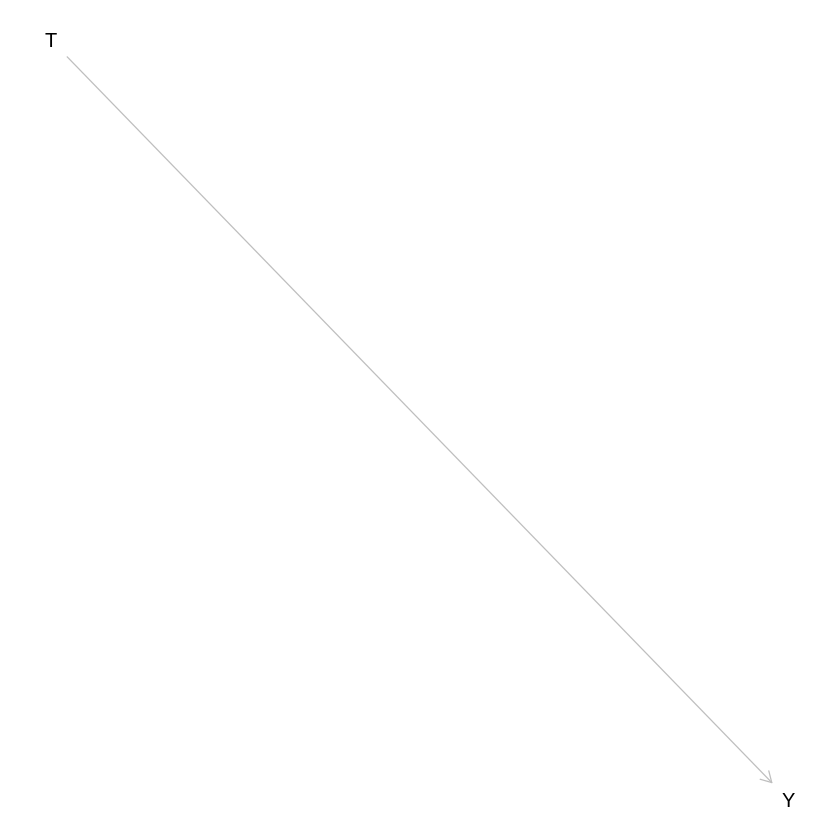

In [37]:
# STEP 1: BASIC DAG – Education (T) → Income (Y)
# Intuition: We start from the fundamental relationship where education (T) directly influences income (Y).
dag0 <- dagitty("dag {
  T -> Y
}")
plot(graphLayout(dag0))

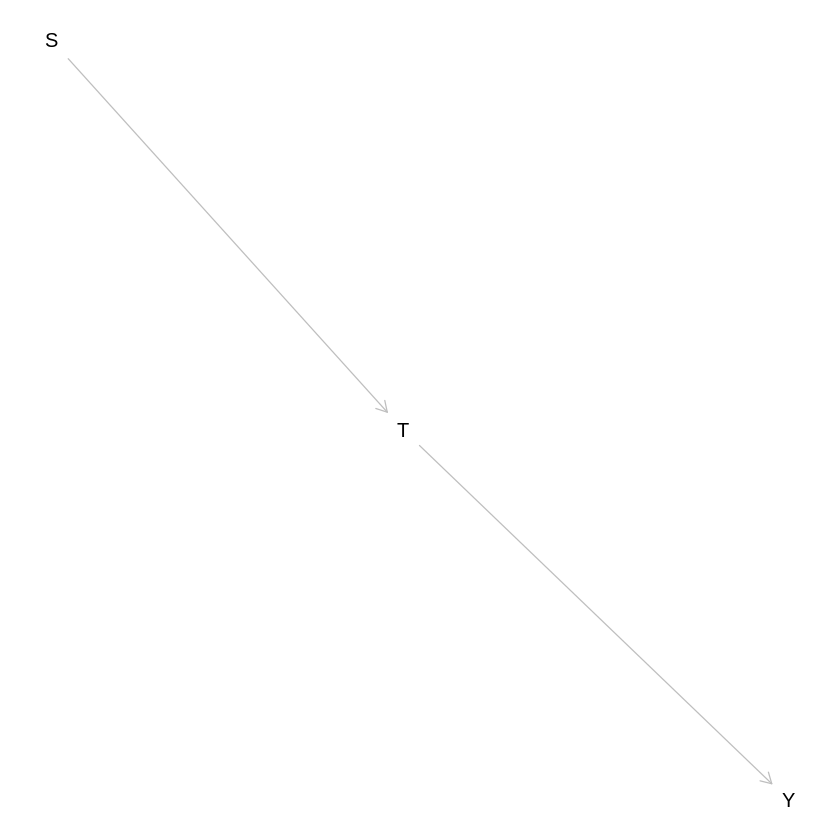

In [38]:
# STEP 2: Add Educational System (S)
# Intuition: The quality or characteristics of the educational system (S) influence education (T).
dag1 <- dagitty("dag {
    T -> Y
    S -> T
}")
plot(graphLayout(dag1))

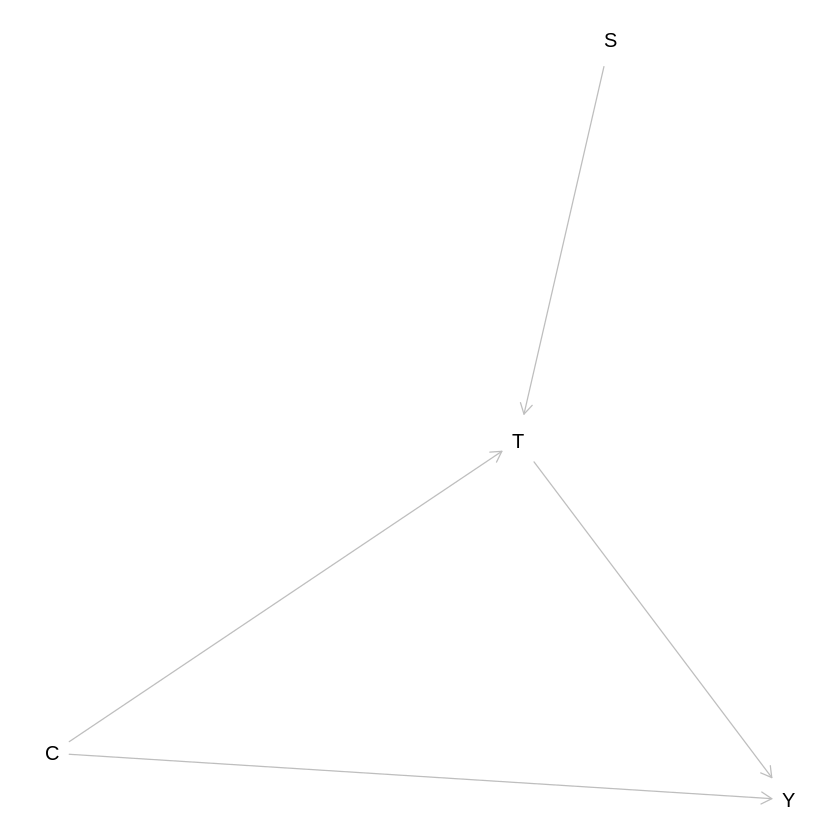

In [39]:
# STEP 3: Add Cohort (C)
# Intuition: The cohort (C) affects education (T) and can also directly influence income (Y) by capturing generational effects.
dag2 <- dagitty("dag {
    T -> Y
    S -> T
    C -> T
    C -> Y
}")
plot(graphLayout(dag2))

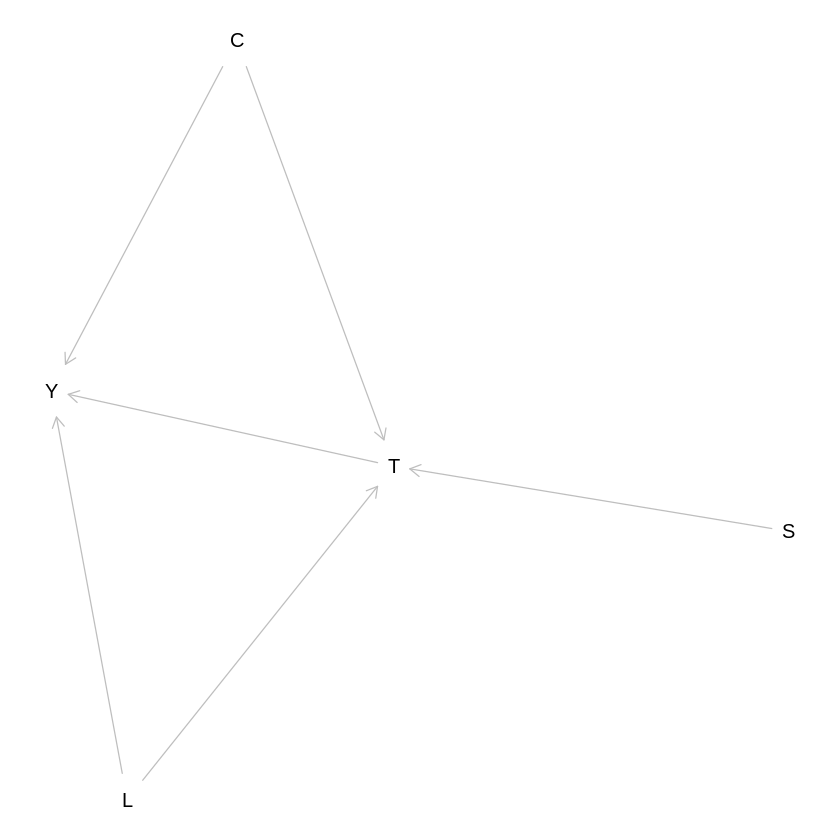

In [40]:
# STEP 4: Add Location (L)
# Intuition: Location (L) affects education (T) and income (Y),
# reflecting geographical variations in opportunities and resources.
dag3 <- dagitty("dag {
    T -> Y
    S -> T
    C -> T
    C -> Y
    L -> T
    L -> Y
}")
plot(graphLayout(dag3))

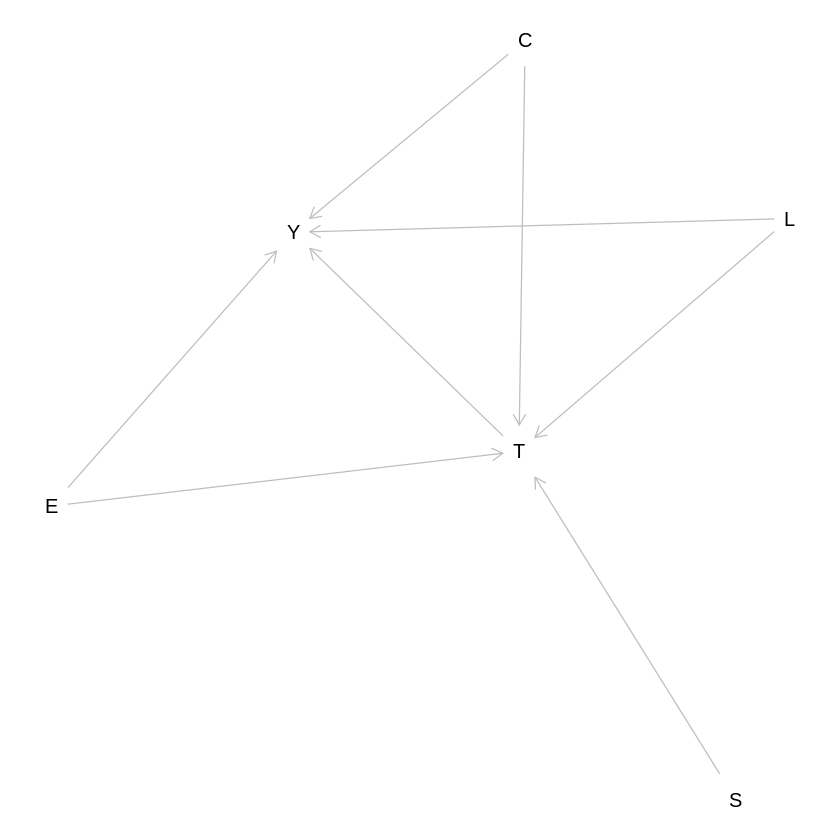

In [41]:
# STEP 5: Add Socioeconomic Status (E)
# Intuition: Socioeconomic status (E) influences both education (T) and directly income (Y), reflecting inequalities derived from socioeconomic background.
dag4 <- dagitty("dag {
    T -> Y
    S -> T
    C -> T
    C -> Y
    L -> T
    L -> Y
    E -> T
    E -> Y
}")
plot(graphLayout(dag4))

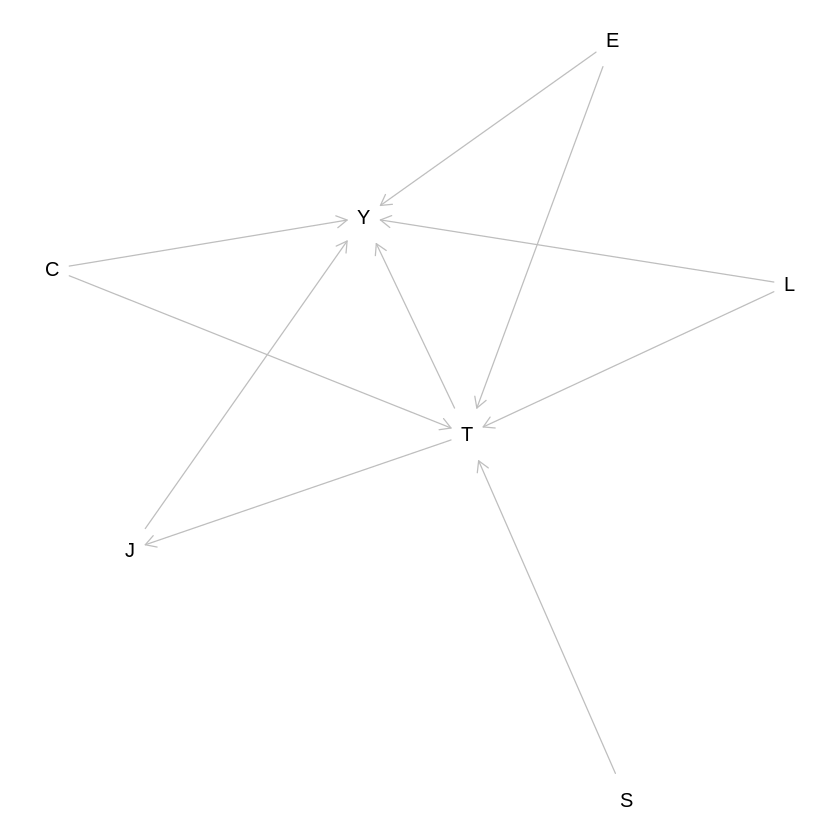

In [42]:
# STEP 6: Add Job Context (J)
# Intuition: Education (T) improves the job context (J), and this in turn influences income (Y).
dag5 <- dagitty("dag {
    T -> Y
    S -> T
    C -> T
    C -> Y
    L -> T
    L -> Y
    E -> T
    E -> Y
    T -> J
    J -> Y
}")
plot(graphLayout(dag5))

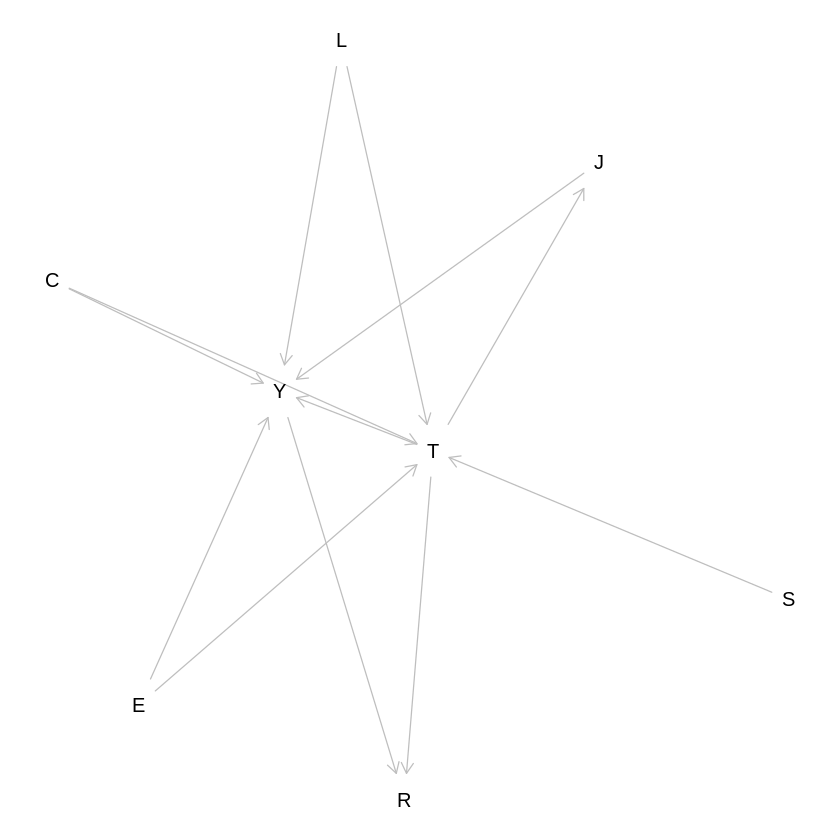

In [43]:
# STEP 7: Add Performance (R)
# Intuition: Performance (R) is determined by education (T) and income (Y), acting as a category associated with these factors.
dag6 <- dagitty("dag {
    T -> Y
    S -> T
    C -> T
    C -> Y
    L -> T
    L -> Y
    E -> T
    E -> Y
    T -> J
    J -> Y
    T -> R
    Y -> R
}")
plot(graphLayout(dag6))

## Exploring final DAG

In [44]:
# Parents (direct causes) of Y:
parents(dag6, "Y")

[1] "C" "E" "J" "L" "T"

In [45]:
# Direct children of E (immediate effects of status):
children(dag6, "E")


[1] "T" "Y"

In [46]:
# Ancestors of Y (all precursors):
ancestors(dag6, "Y")

[1] "Y" "T" "S" "L" "J" "E" "C"

In [47]:
# Descendants of S (effects derived from the educational system):
descendants(dag6, "S")

[1] "S" "T" "Y" "R" "J"

## "Key" control variables

In [48]:
# Variables to control for are identified to unbiasedly estimate the causal effect of education (T) on income (Y).
adjustmentSets(dag6, exposure = "T", outcome = "Y")

{ C, E, L }



     T  : Education (The primary Causal Variable or 'Treatment' whose effect we want to estimate)
     Y  : Income (The primary Outcome Variable we believe is affected by Education)
     C  : Cohort (The generation or time period someone belongs to, e.g., born in 1980s vs 1990s, influencing opportunities and norms)
     L  : Location (Geographic context, e.g., urban/rural, region, which affects resources and job markets)
     E  : Socioeconomic Status (Background factors, often relating to family origin, like parental income/education)

## Plot final DAG

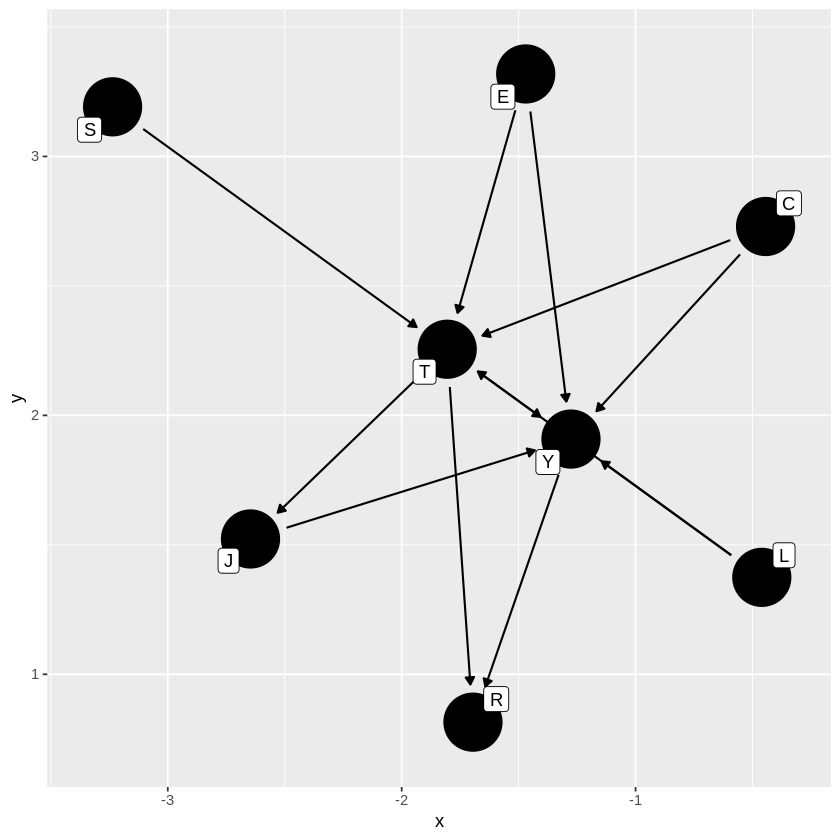

In [49]:
# Clean visualization of the final DAG.
ggdag(dag6, text = FALSE, use_labels = "name")

    T -> Y  # Education -> Income
    S -> T  # System -> Education
    C -> T  # Cohort -> Education
    C -> Y  # Cohort -> Income
    L -> T  # Location -> Education
    L -> Y  # Location -> Income
    E -> T  # Socioeconomic Status -> Education
    E -> Y  # Socioeconomic Status -> Income
    T -> J  # Education -> Job Context
    J -> Y  # Job Context -> Income
    T -> R  # Education -> Performance/Well-being
    Y -> R  # Income -> Performance/Well-being

## Conditional independence

In [50]:
# Some conditional independencies inferred from the DAG are explored.
impliedConditionalIndependencies(dag6)

C _||_ E
C _||_ J | T
C _||_ L
C _||_ R | T, Y
C _||_ S
E _||_ J | T
E _||_ L
E _||_ R | T, Y
E _||_ S
J _||_ L | T
J _||_ R | T, Y
J _||_ S | T
L _||_ R | T, Y
L _||_ S
R _||_ S | C, E, L, T
R _||_ S | T, Y
S _||_ Y | C, E, L, T

1.  **`C _||_ E`** (Cohort is independent of Socioeconomic Status)
    * **Paths:** Any path from C to E must pass through their common children T or Y (or descendants J, R). Examples: `C -> T <- E`, `C -> Y <- E`.
    * **Blocking:** In these paths, T and Y are colliders (arrows point into them from C and E). Since we are *not* conditioning on T or Y (or their descendants R, J), these paths are **blocked** at the colliders.
    * **Explanation:** The DAG assumes C and E are distinct external factors influencing education and income; they don't influence each other. Their association only potentially arises if we were to condition on their common effects.

2.  **`C _||_ J | T`** (Cohort is independent of Job Context given Education)
    * **Paths:** The main directed path is `C -> T -> J`. Another path involves Y: `C -> Y <- J`.
    * **Blocking:** We condition on T.
        * Path `C -> T -> J`: T is a non-collider (mediator). Conditioning on T **blocks** this path.
        * Path `C -> Y <- J`: Y is a collider (`C->Y`, `J->Y`). Conditioning on T (neither Y nor its descendant R) does *not* open this path. It remains blocked.
    * **Explanation:** The DAG assumes the entire influence of Cohort (C) on Job Context (J) passes through Education (T). Once T is known, C provides no further information about J.

3.  **`C _||_ L`** (Cohort is independent of Location)
    * **Paths:** Meet at colliders T (`C -> T <- L`) and Y (`C -> Y <- L`).
    * **Blocking:** Blocked by unconditioned colliders T and Y.
    * **Explanation:** Assumed to be independent exogenous factors.

4.  **`C _||_ R | T, Y`** (Cohort is independent of Performance/Well-being given Education and Income)
    * **Paths:** `C -> T -> R` and `C -> Y -> R`.
    * **Blocking:** We condition on T and Y.
        * Path `C -> T -> R`: Conditioning on non-collider T **blocks** this path.
        * Path `C -> Y -> R`: Conditioning on non-collider Y **blocks** this path.
    * **Explanation:** R is assumed to be directly caused only by T and Y. Once T and Y are known, C (an ancestor of T and Y) adds no more information about R.

5.  **`C _||_ S`** (Cohort is independent of Educational System)
    * **Paths:** `C -> T <- S`.
    * **Blocking:** Blocked by unconditioned collider T.
    * **Explanation:** Assumed independent exogenous factors.

6.  **`E _||_ J | T`** (Socioeconomic Status is independent of Job Context given Education)
    * **Paths:** `E -> T -> J`, `E -> Y <- J`.
    * **Blocking:** Conditioning on T blocks the mediated path `E -> T -> J`. The collider path `E -> Y <- J` remains blocked.
    * **Explanation:** Similar to C, the influence of E on J is assumed to be fully mediated by T.

7.  **`E _||_ L`** (Socioeconomic Status is independent of Location)
    * **Paths:** `E -> T <- L`, `E -> Y <- L`.
    * **Blocking:** Blocked by unconditioned colliders T, Y.
    * **Explanation:** Assumed independent exogenous factors.

8.  **`E _||_ R | T, Y`** (Socioeconomic Status is independent of Performance/Well-being given Education and Income)
    * **Paths:** `E -> T -> R`, `E -> Y -> R`.
    * **Blocking:** Conditioning on T blocks the first path. Conditioning on Y blocks the second path.
    * **Explanation:** Similar to C, once direct causes T and Y are known, ancestor E provides no further information about R.

9.  **`E _||_ S`** (Socioeconomic Status is independent of Educational System)
    * **Paths:** `E -> T <- S`.
    * **Blocking:** Blocked by unconditioned collider T.
    * **Explanation:** Assumed independent exogenous factors.

10. **`J _||_ L | T`** (Job Context is independent of Location given Education)
    * **Paths:** `J <- T <- L`, `J -> Y <- L`.
    * **Blocking:** Conditioning on T blocks the path `J <- T <- L`. The path `J -> Y <- L` involves collider Y, which is not conditioned on (nor is R), so it remains blocked.
    * **Explanation:** Any association between J and L is assumed to be via T or the collider Y. Conditioning on T blocks the first route, and the second is already blocked.

11. **`J _||_ R | T, Y`** (Job Context is independent of Performance/Well-being given Education and Income)
    * **Paths:** `J <- T -> R`, `J -> Y -> R`.
    * **Blocking:** Conditioning on T blocks the first path. Conditioning on Y blocks the second path.
    * **Explanation:** Once the direct causes of R (T and Y) are known, J (which is influenced by T and influences Y) becomes independent of R.

12. **`J _||_ S | T`** (Job Context is independent of Educational System given Education)
    * **Paths:** `J <- T <- S`.
    * **Blocking:** Conditioning on T blocks this path.
    * **Explanation:** The link between S and J is mediated entirely through T.

13. **`L _||_ R | T, Y`** (Location is independent of Performance/Well-being given Education and Income)
    * **Paths:** `L -> T -> R`, `L -> Y -> R`.
    * **Blocking:** Conditioning on T blocks the first path. Conditioning on Y blocks the second path.
    * **Explanation:** Similar to C and E, once direct causes T and Y are known, ancestor L provides no further information about R.

14. **`L _||_ S`** (Location is independent of Educational System)
    * **Paths:** `L -> T <- S`.
    * **Blocking:** Blocked by unconditioned collider T.
    * **Explanation:** Assumed independent exogenous factors.

15. **`R _||_ S | C, E, L, T`** (Performance/Well-being is independent of Educational System given C, E, L, T)
    * **Paths:** The only path is `R <- T <- S`.
    * **Blocking:** Conditioning on T **blocks** this path. Conditioning on C, E, L (other ancestors of T) is irrelevant for blocking *this* path.
    * **Explanation:** The only connection from S to R goes via T. Knowing T disconnects S from R.

16. **`R _||_ S | T, Y`** (Performance/Well-being is independent of Educational System given Education, Income)
    * **Paths:** Only `R <- T <- S`.
    * **Blocking:** Conditioning on T **blocks** this path. Conditioning on Y is irrelevant for this path.
    * **Explanation:** Same reason as #15. Conditioning on T is sufficient to block the path.

17. **`S _||_ Y | C, E, L, T`** (Educational System is independent of Income given C, E, L, T)
    * **Paths:** `S -> T -> Y`, `S -> T -> J -> Y`. Also potentially `S -> T -> R <- Y`.
    * **Blocking:** Conditioning on T blocks `S -> T -> Y` and `S -> T -> J -> Y`. The path `S -> T -> R <- Y` contains collider R. Since R is not in the conditioning set {C,E,L,T}, this path is also blocked.
    * **Explanation:** All paths from S to Y must first pass through T. Conditioning on T blocks all these connections.

# Simulated example

### Create simulated dataset

In [51]:
set.seed(123)      # For reproducibility
n <- 1000          # Sample size

# Exogenous variables (simulated as normal variables):
S <- rnorm(n, mean = 0, sd = 1)   # Educational system (quality)
C <- rnorm(n, mean = 0, sd = 1)   # Cohort (generational effects)
L <- rnorm(n, mean = 0, sd = 1)   # Location (geographic context)
E <- rnorm(n, mean = 0, sd = 1)   # Socioeconomic status (background)

# Endogenous variables simulated according to the DAG:
# Education (T) is influenced by S, C, L, and E.
T <- 0.5 * S + 0.3 * C + 0.4 * L + 0.4 * E + rnorm(n, 0, 1)

# Job context (J) depends on T.
J <- 0.6 * T + rnorm(n, 0, 1)

# Income (Y) is directly influenced by T, C, L, E and mediated by J.
Y <- 0.5 * T + 0.4 * C + 0.3 * L + 0.3 * E + 0.7 * J + rnorm(n, 0, 1)

# Performance (R) is determined by T and Y.
R <- 0.3 * T + 0.3 * Y + rnorm(n, 0, 1)

# Create a data frame with the simulated data:
df <- data.frame(S, C, L, E, T, J, Y, R)

In [52]:
head(df)

,S,C,L,E,T,J,Y,R
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.56047565,-0.99579872,-0.5116037,-0.15030748,-0.6471921,-0.88248917,-2.23745944,-2.4834322
2,-0.23017749,-1.03995504,0.2369379,-0.32775713,0.1867102,1.23961960,1.51431257,0.8894880
3,1.55870831,-0.01798024,-0.5415892,-1.44816529,0.6490625,-0.75751206,-1.50259098,1.6461919
4,0.07050839,-0.13217513,1.2192276,-0.69728458,-1.0797789,0.83315127,0.04354626,0.2910045
5,0.12928774,-2.54934277,0.1741359,2.59849023,-1.6172181,-0.05413965,-0.43059002,1.1180073
6,1.71506499,1.04057346,-0.6152683,-0.03741501,3.1139573,2.20350537,2.71181179,1.6008612


### Model estimation

In [53]:
# Model 1: Simple regression of Y on T (unadjusted)
m1 <- lm(Y ~ T, data = df)
summary(m1)


Call:
lm(formula = Y ~ T, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.5545 -0.8529 -0.0068  0.8385  4.1782 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.004528   0.041219    0.11    0.913    
T           1.140686   0.031052   36.73   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.303 on 998 degrees of freedom
Multiple R-squared:  0.5749,	Adjusted R-squared:  0.5744 
F-statistic:  1349 on 1 and 998 DF,  p-value: < 2.2e-16


In [54]:
# Model 2: Adjusted regression including key variables (C, L, and E) to reduce confounding bias
m2 <- lm(Y ~ T + C + L + E, data = df)
summary(m2)


Call:
lm(formula = Y ~ T + C + L + E, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.7468 -0.8115  0.0258  0.8399  3.7057 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.00897    0.03816  -0.235    0.814    
T            0.90317    0.03396  26.596  < 2e-16 ***
C            0.39383    0.04056   9.711  < 2e-16 ***
L            0.28801    0.04101   7.022 4.04e-12 ***
E            0.31808    0.04080   7.796 1.60e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.205 on 995 degrees of freedom
Multiple R-squared:  0.6377,	Adjusted R-squared:  0.6363 
F-statistic: 437.9 on 4 and 995 DF,  p-value: < 2.2e-16


### Diagnostic plots

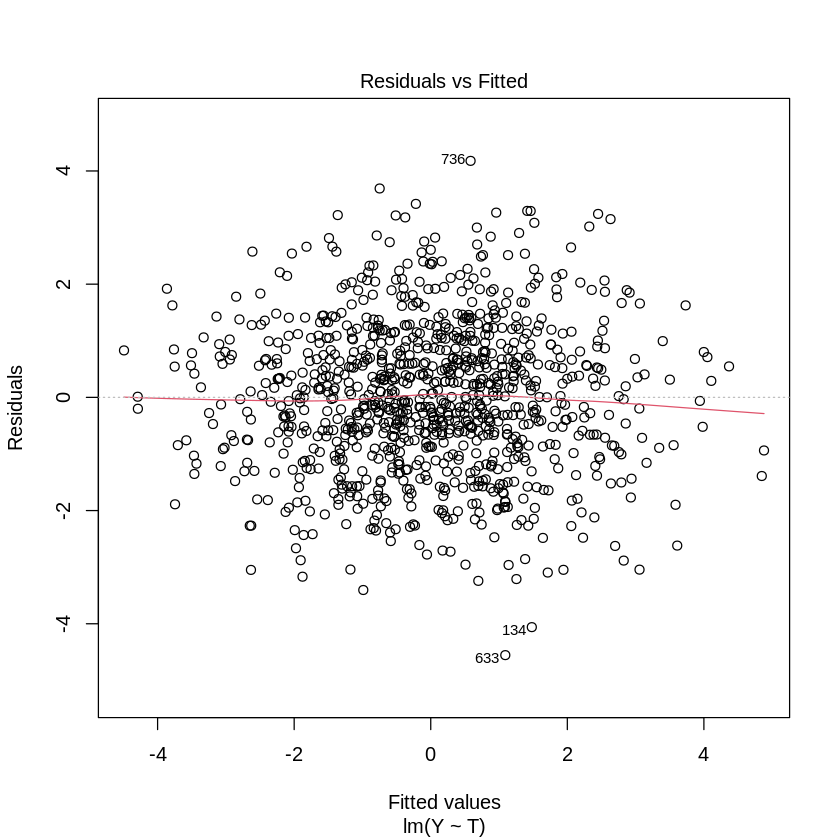

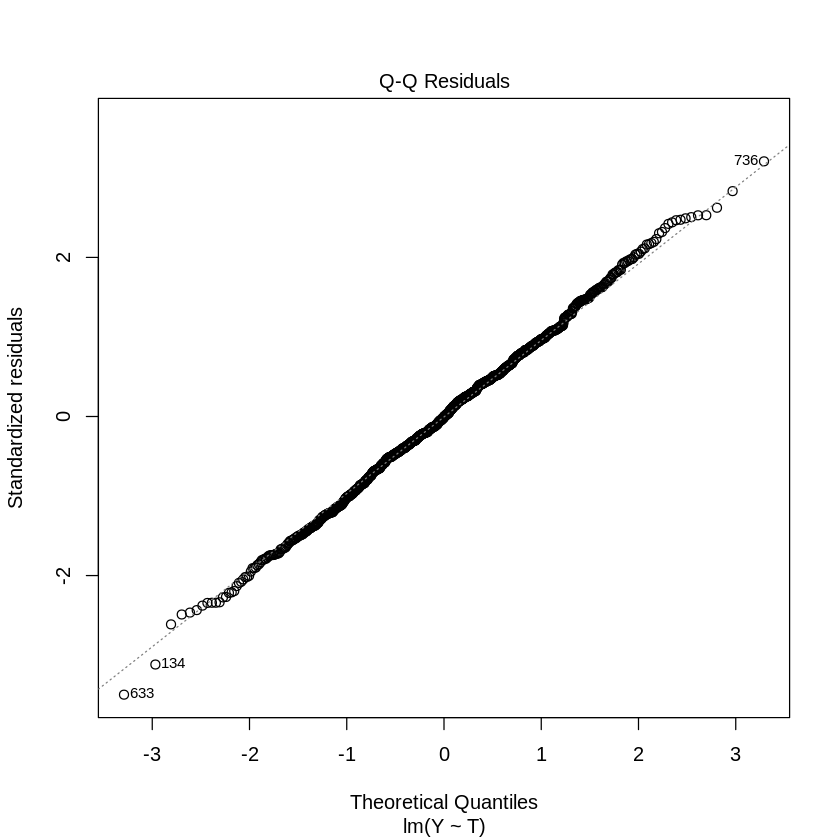

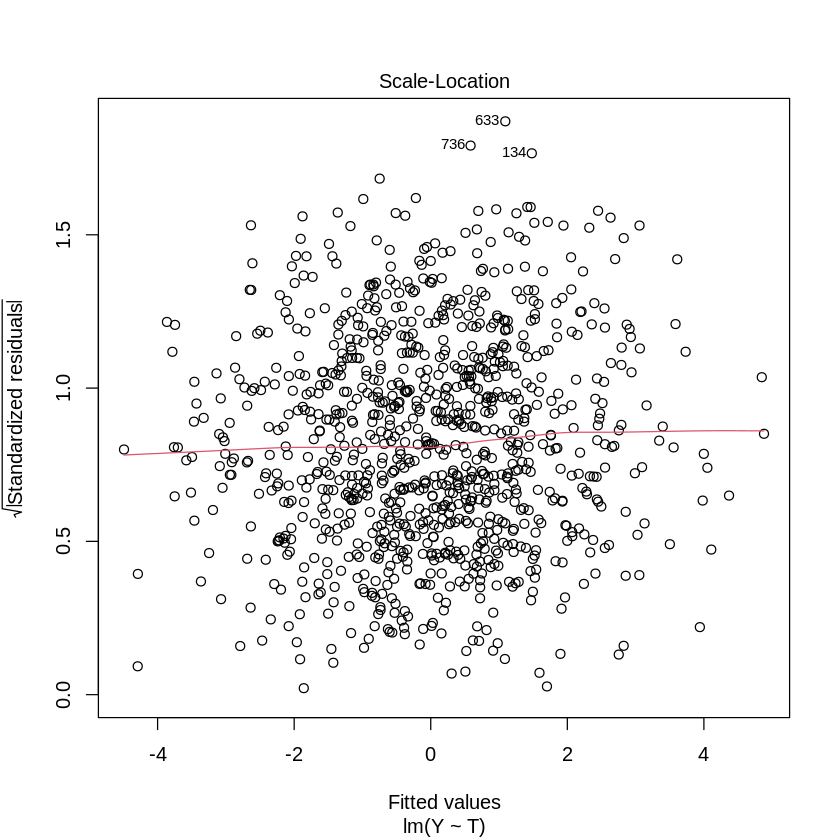

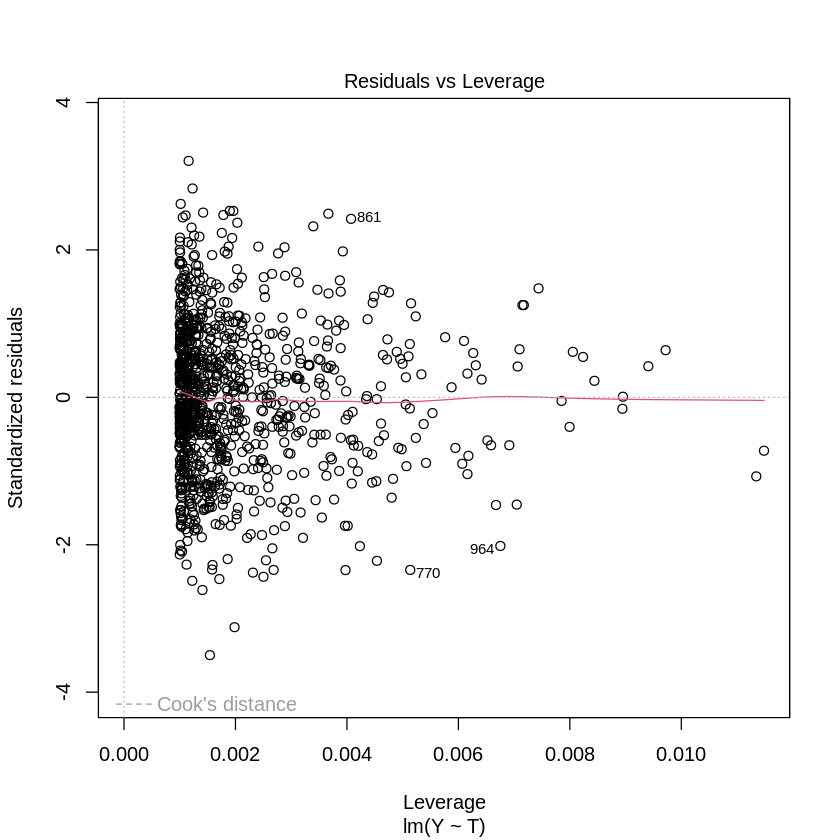

In [55]:
plot(m1)

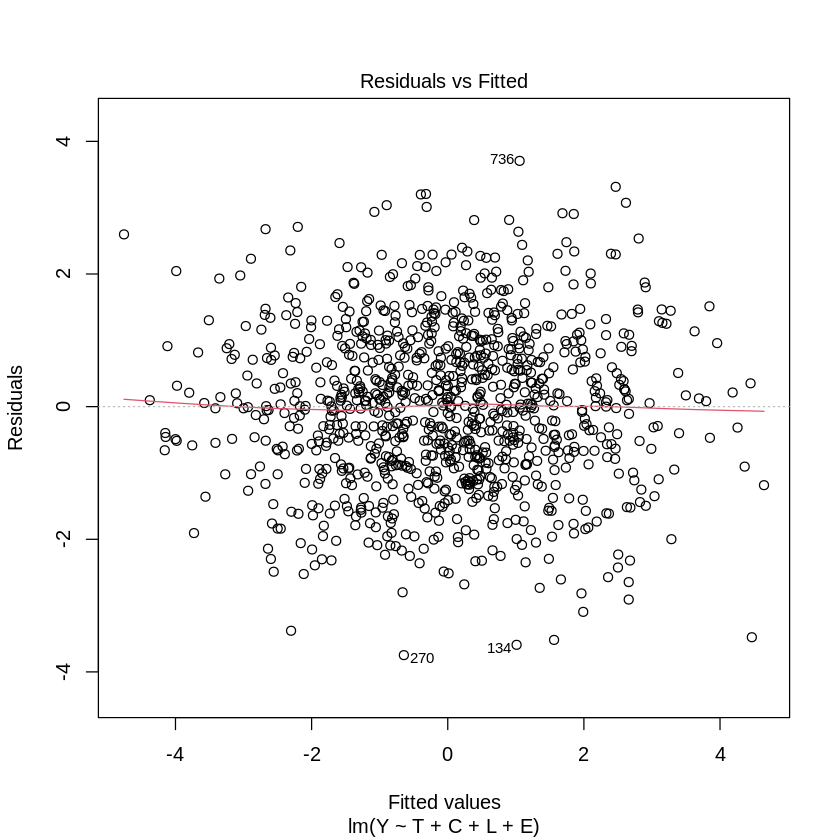

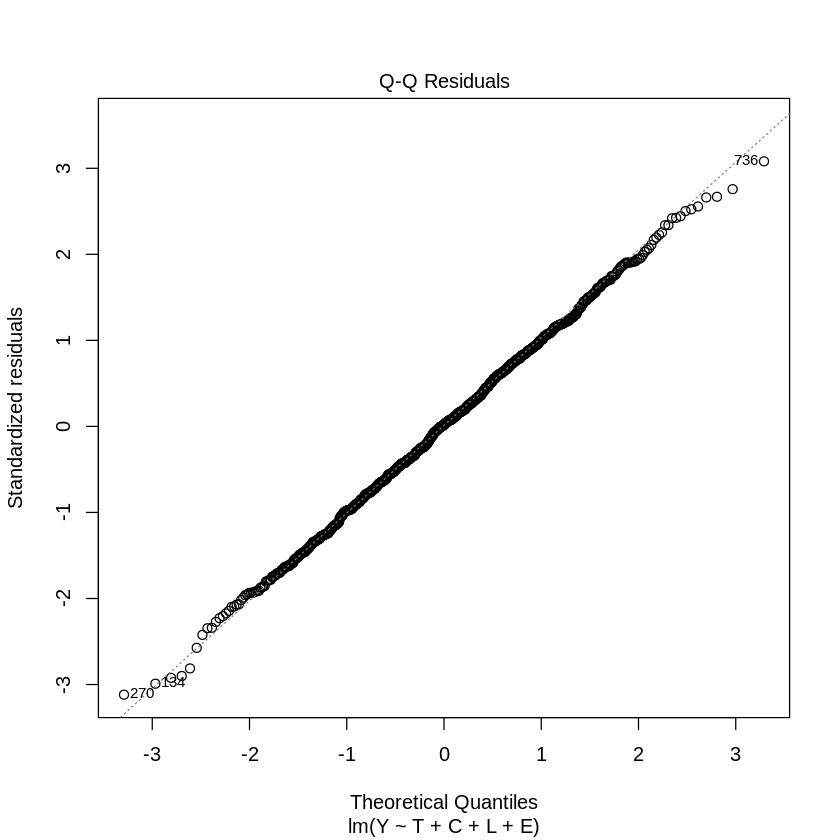

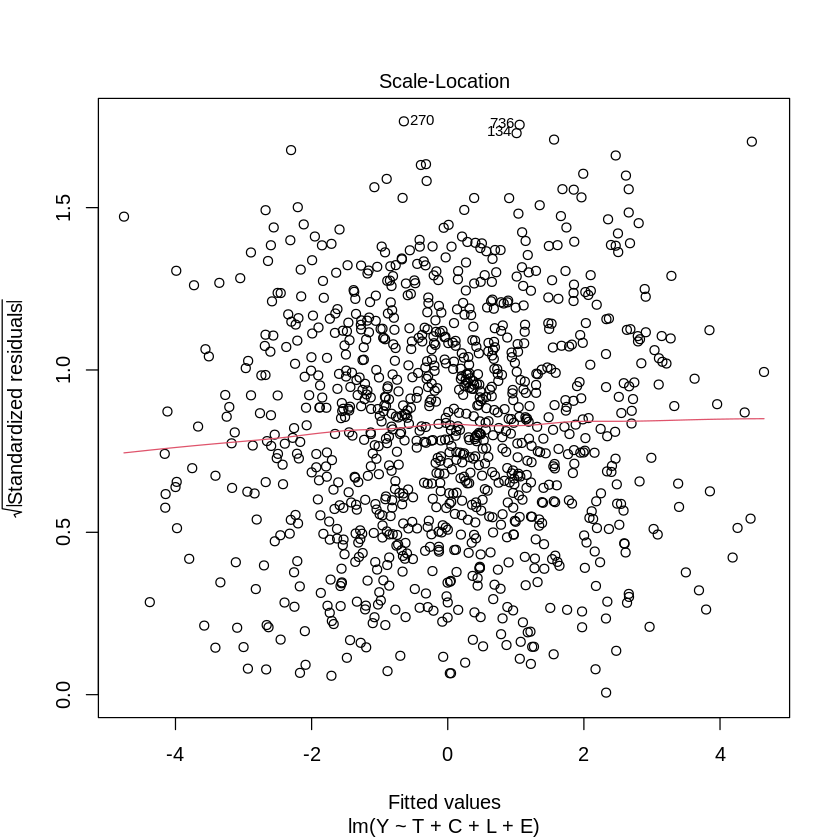

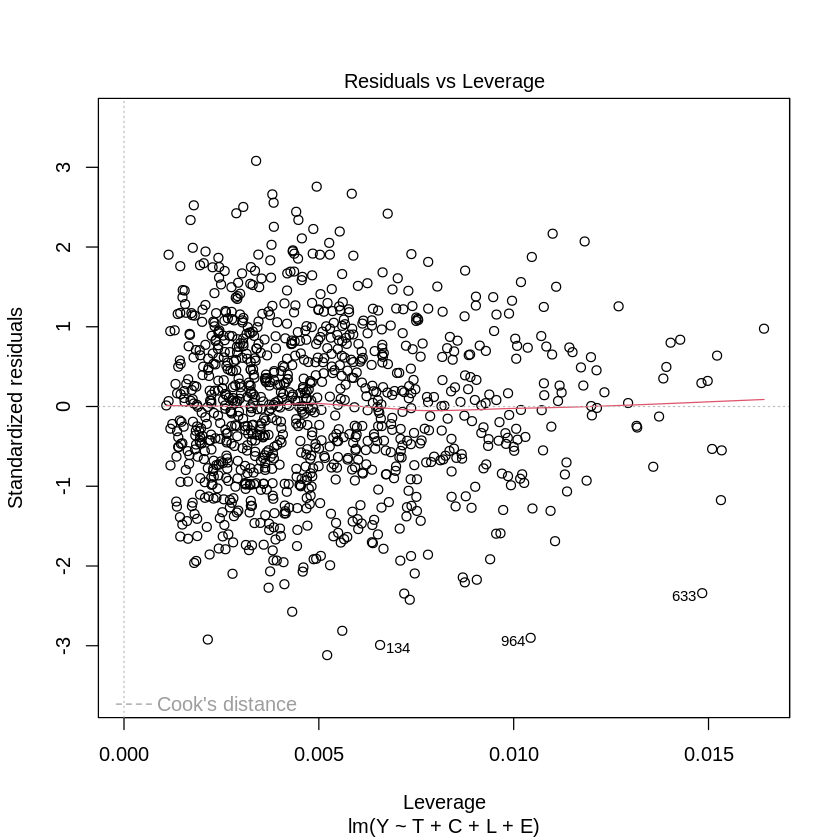

In [56]:
plot(m2)

### Correlation between T and Y

In [57]:
cor(df$T, df$Y)

[1] 0.7581963

A high correlation between T and Y does not necessarily imply a causal relationship, hence the importance of adjusting for confounding variables as suggested by the DAG.

# Acknowledgment
Part of code and content of this notebook is inspired by the execellent learning materials of [Curso Ejecutivo Virtual: ENFOQUES Y MÉTODOS CAUSALES PARA LA EVALUACIÓN DE IMPACTO (Cuarta versión)](https://www.inesad.edu.bo/2025/02/27/curso-ejecutivo-virtual-enfoques-y-metodos-causales-para-la-evaluacion-de-impacto-cuarta-version/)